## Student Experience Topic Overview Analysis

This notebook analyzes YouTube comments and videos discussing **overall student experience** across Indian universities. It follows the same technique set used in the Placement, Fees, and Hostel analyses (cleaning, TF, TF-IDF, word cloud, engagement, sentiment, topic modeling, university-wise and trend analysis), and adds a **student-experience-specific layer**: tagging comments into experience aspects (academics/faculty, placements, campus life, hostel, fees, ragging/safety, social life, discipline, location), detecting explicit **recommend-vs-regret signals** ('worth it' / 'don't join this college'), and flagging comments that carry a **current-student/alumni voice** (self-identified 'I am from...', '3rd year', 'alumni') since those carry more credibility than a random viewer's question. It also adds a **video-type classification** (Review/Honest Opinion, Comparison/Ranking, Vlog/Campus Tour, Fee/Placement Info) on the video-level dataset.

### TECHNIQUE 1: Data Cleaning & Preprocessing

#### Clean noisy text

##### Why this Technique was Used

Data preprocessing helps in:
Removing noisy and irrelevant information.
Improving text consistency.
Preparing data for frequency analysis, sentiment analysis, and topic modeling.
Reducing errors in downstream NLP tasks.

In [1]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import re

# Set the plotting backend to inline explicitly (works even if this
# notebook is restarted, run cell-by-cell, or run out of order) so every
# plt.show() below actually renders a chart instead of doing nothing.
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("png")
import matplotlib.pyplot as plt

# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv(
    "india_universities_student_experience_comments.csv"
)

df.head()

,comment_id,thread_id,parent_comment_id,video_id,video_title,channel_name,university_name,category,keyword,author_name,...,comment_month,likes,reply_count,is_reply,comment_type,comment_length,word_count,contains_question,contains_url,contains_emoji
0,UgwawAD6tkd8QsDSeyp4AaABAg,UgwawAD6tkd8QsDSeyp4AaABAg,NaN,AFhvjEaQVlQ,"Classroom view || Faculty of Technology, Delhi...",DuChhatra,IIT Delhi,student_experience,student review,@aashi634,...,6,0,0,False,parent,13,2,True,False,False
1,UgzPcROaNJwrgZBAdFl4AaABAg,UgzPcROaNJwrgZBAdFl4AaABAg,NaN,AFhvjEaQVlQ,"Classroom view || Faculty of Technology, Delhi...",DuChhatra,IIT Delhi,student_experience,student review,@aashi634,...,6,0,0,False,parent,38,8,True,False,False
2,UgxsR_xpEaPBXqsa6F94AaABAg,UgxsR_xpEaPBXqsa6F94AaABAg,NaN,AFhvjEaQVlQ,"Classroom view || Faculty of Technology, Delhi...",DuChhatra,IIT Delhi,student_experience,student review,@RaghavBansal-o7r,...,5,0,1,False,parent,36,10,True,False,False
3,UgxsR_xpEaPBXqsa6F94AaABAg.AXE9_54rrBiAXH0QH2KzTp,UgxsR_xpEaPBXqsa6F94AaABAg,UgxsR_xpEaPBXqsa6F94AaABAg,AFhvjEaQVlQ,"Classroom view || Faculty of Technology, Delhi...",DuChhatra,IIT Delhi,student_experience,student review,@Sunnylegend16,...,5,0,0,True,reply,15,3,False,False,False
4,UgyrpzF_ky3a5SjYcKF4AaABAg,UgyrpzF_ky3a5SjYcKF4AaABAg,NaN,AFhvjEaQVlQ,"Classroom view || Faculty of Technology, Delhi...",DuChhatra,IIT Delhi,student_experience,student review,@user-vn4jw8et3t,...,5,0,2,False,parent,66,12,False,False,False


In [2]:
# ==========================================
# Missing Value Analysis
# ==========================================

df.isnull().sum()

comment_id               0
thread_id                0
parent_comment_id    36880
video_id                 0
video_title              0
channel_name             0
university_name          0
category                 0
keyword                  0
author_name              0
comment_text             4
published_at             0
comment_date             0
comment_year             0
comment_month            0
likes                    0
reply_count              0
is_reply                 0
comment_type             0
comment_length           0
word_count               0
contains_question        0
contains_url             0
contains_emoji           0
dtype: int64

In [3]:
# ==========================================
# Remove Empty Comments
# ==========================================

df = df.dropna(
    subset=["comment_text"]
)

print("Rows after cleaning:", len(df))

Rows after cleaning: 63857


In [4]:
# ==========================================
# Text Cleaning Function
# ==========================================

def clean_text(text):

    text = str(text)

    # Remove URLs only
    text = re.sub(
        r"http\S+|www\S+",
        "",
        text
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

df["clean_comment"] = df["comment_text"].apply(clean_text)

df[["comment_text", "clean_comment"]].head()

,comment_text,clean_comment
0,Cuet cutoff??,Cuet cutoff??
1,Bsc biotech ki classes same h ua alg??,Bsc biotech ki classes same h ua alg??
2,"100271 crl ews , cse mil skti h , ??","100271 crl ews , cse mil skti h , ??"
3,Mil jayega Bhai,Mil jayega Bhai
4,Hlo.....CRL 267k hh OBC-NCL EE mil skta haii k...,Hlo.....CRL 267k hh OBC-NCL EE mil skta haii k...


In [5]:
# ==========================================
# Duplicate Analysis
# ==========================================

duplicates = df.duplicated(
    subset=["comment_id"]
).sum()

print(
    "Duplicate Comments:",
    duplicates
)

Duplicate Comments: 0


In [6]:
# ==========================================
# Dataset Summary
# ==========================================

print("Universities:",
      df["university_name"].nunique())

print("Videos:",
      df["video_id"].nunique())

print("Comments:",
      len(df))

Universities: 98
Videos: 935
Comments: 63857


# 4.2 Comment Length Analysis

## Objective

Comment length analysis was performed to understand the depth and engagement level of discussions related to student experience. Longer comments generally indicate detailed personal accounts of campus life, academics, or regrets, whereas shorter comments often represent quick reactions ('nice college', 'is it worth it?').

#### 1. Calculate Comment Length

In [7]:
# ==========================================
# Comment Length Analysis
# ==========================================

df["comment_length"] = (
    df["clean_comment"]
    .str.len()
)

df[
    [
        "clean_comment",
        "comment_length"
    ]
].head()

,clean_comment,comment_length
0,Cuet cutoff??,13
1,Bsc biotech ki classes same h ua alg??,38
2,"100271 crl ews , cse mil skti h , ??",36
3,Mil jayega Bhai,15
4,Hlo.....CRL 267k hh OBC-NCL EE mil skta haii k...,66


#### 2. Basic Statistics

In [8]:
# ==========================================
# Length Statistics
# ==========================================

print(
    df["comment_length"]
    .describe()
)

count    63857.000000
mean        68.369278
std        113.048942
min          0.000000
25%         22.000000
50%         41.000000
75%         77.000000
max       7442.000000
Name: comment_length, dtype: float64


#### 3. Average Length

In [9]:
print(
    "Average Comment Length:",
    round(
        df["comment_length"].mean(),
        2
    )
)

Average Comment Length: 68.37


#### 4. Histogram

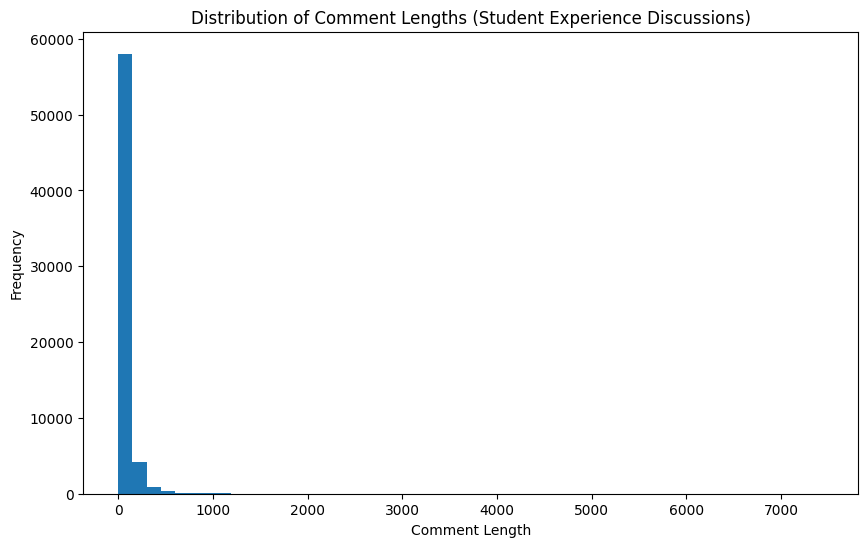

In [10]:
plt.figure(
    figsize=(10,6)
)

plt.hist(
    df["comment_length"],
    bins=50
)

plt.title(
    "Distribution of Comment Lengths (Student Experience Discussions)"
)

plt.xlabel(
    "Comment Length"
)

plt.ylabel(
    "Frequency"
)

plt.show()

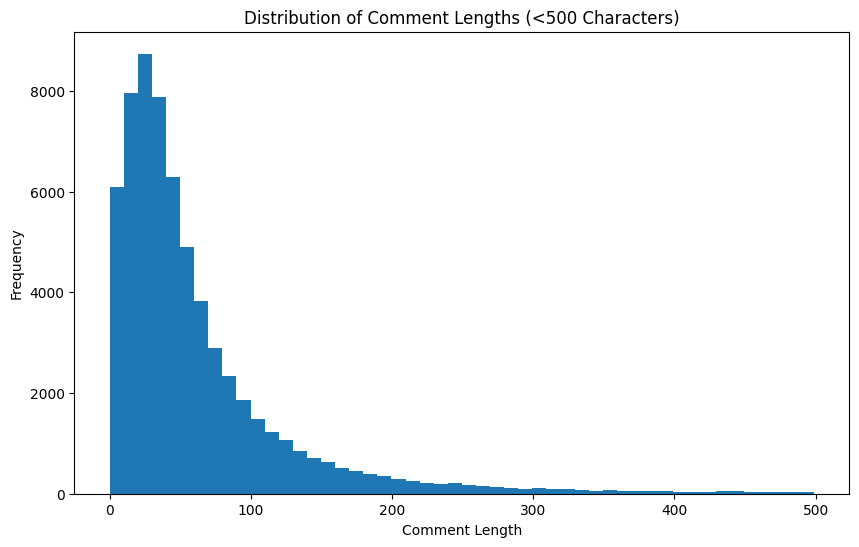

In [11]:
plt.figure(figsize=(10,6))

plt.hist(
    df[df["comment_length"] < 500]["comment_length"],
    bins=50
)

plt.title(
    "Distribution of Comment Lengths (<500 Characters)"
)

plt.xlabel("Comment Length")
plt.ylabel("Frequency")

plt.show()

### Interpretation of Comment Length Distribution

The histogram is right-skewed, with the mean comment length (~68 characters) sitting well above the median (41 characters) — even more pronounced than the Fees and Hostel comment sets. Most student-experience comments are short reactions or one-line questions ('worth it?', 'how's the campus?'), while a smaller share of long comments contain detailed personal accounts — full paragraphs about academics, placements, ragging, or "why I regret joining" stories.

#### 5. Box Plot

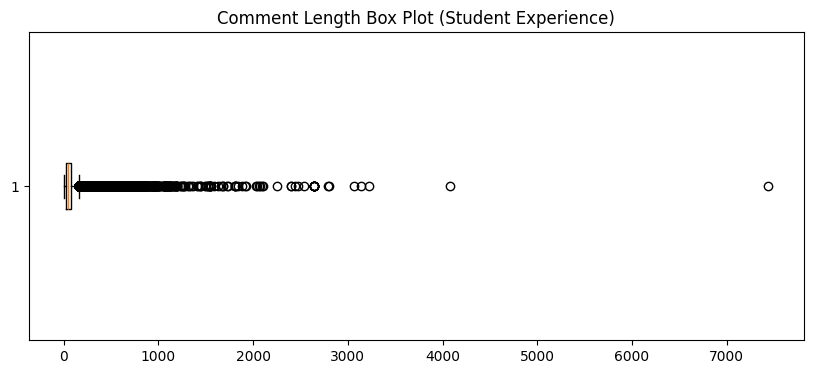

In [12]:
plt.figure(
    figsize=(10,4)
)

plt.boxplot(
    df["comment_length"],
    vert=False
)

plt.title(
    "Comment Length Box Plot (Student Experience)"
)

plt.show()

Box = Middle 50% of comments (IQR)

Orange line = Median comment length

Dots = Outliers (long, detailed comments)

#### 6. University-wise Average Comment Length

In [13]:
avg_length = (

    df.groupby(
        "university_name"
    )["comment_length"]

    .mean()

    .sort_values(
        ascending=False
    )

    .head(15)
)

avg_length

university_name
IIIT Kottayam                                     152.101810
PES University                                    132.010638
IIM Ranchi                                        110.198473
IIM Indore                                        106.711900
IIM Kozhikode                                     102.682785
IIM Rohtak                                         98.729642
IIIT Bangalore                                     97.939351
Christ University                                  97.880769
O.P. Jindal Global University                      89.888587
Galgotias University                               89.396894
IIM Shillong                                       89.070175
IIM Bangalore                                      88.186411
IIT Madras                                         88.060659
Thapar Institute of Engineering and Technology     85.181146
Shiv Nadar University                              84.819760
Name: comment_length, dtype: float64

#### 7. Visualization

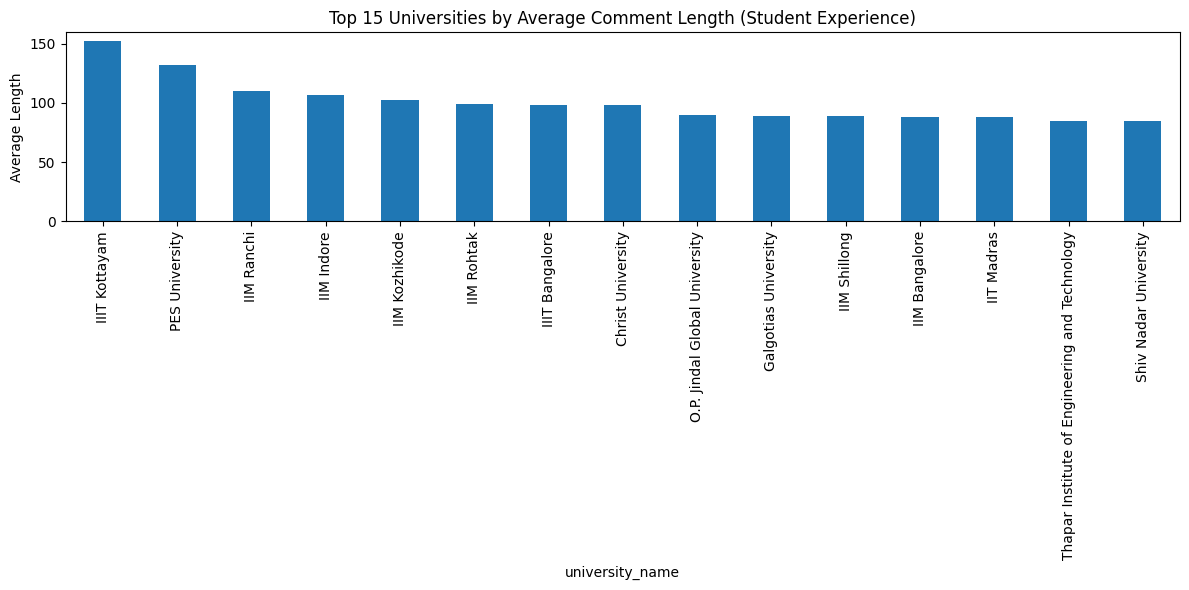

In [14]:
plt.figure(
    figsize=(12,6)
)

avg_length.plot(
    kind="bar"
)

plt.title(
    "Top 15 Universities by Average Comment Length (Student Experience)"
)

plt.ylabel(
    "Average Length"
)

plt.tight_layout()
plt.show()

## Findings

Comment length analysis revealed the overall depth of engagement in student-experience discussions. IIIT Kottayam and PES University sit well above the rest of the field, with the IIMs also clustering near the top — these are threads where commenters write out detailed, multi-line personal accounts rather than one-word reactions.

# 3 Term Frequency Analysis

## Objective

Term Frequency (TF) analysis was performed to identify the most frequently occurring words in student-experience comments, to understand the dominant themes (placement, campus, hostel, fees, branch, faculty, etc.) that students and prospective students discuss.

In [15]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

True

#### Master Stopword List

A plain English stopword list alone leaves a lot of noise in Hinglish YouTube comments — filler words (hai, sir, please, kya, bro, bhai, bhi, nhi, liye), YouTube-generic words (video, subscribe, comment), and topic-generic words that appear in almost every comment by definition (college, university, student). These are combined into one master stopword list, reused across TF, TF-IDF, word cloud, bigram, and LDA topic modeling below so results stay consistent.

In [16]:
# ==========================================
# Master Stopword List (reused across all NLP techniques below)
# ==========================================

# Hindi / Hinglish filler words commonly seen in YouTube comments
hinglish_stopwords = {
    "hai","ho","h","ka","ki","ke","ko","se","me","mai","mein",
    "aur","ya","ye","yeh","wo","woh","is","us","to","toh","bhi","nhi",
    "nahi","liye","kar","karo","kr","krna","krne","hua","huaa",
    "mujhe","mera","mere","meri","apna","apni","apne","acha","accha",
    "sirf","fir","phir","ab","sab","kuch","bahut","bohot","kya","kese","kaise",
    "kon","kaun","kab","kaha","kahan","wah","agar","koi","uske","uska",
    "iske","iska","kro","kro","hoga","hogi","honge","tha","thi","the",
    "bro","bhai","bhaiya","sir","maam","yaar","dost","plz","pls",
    "chahiye","milega","milegi","kitna","kitni","kaisa","kaisi"
}

# YouTube / engagement-generic words
youtube_stopwords = {
    "video","videos","channel","watch","watched","subscribe",
    "subscribed","like","liked","comment","comments","share","link",
    "please","thanks","thank","good","nice","great","best"
}

# Topic-generic words — appear in almost every comment by definition,
# so they crowd out the words that actually differentiate one comment from another
topic_generic_stopwords = {
    "college","colleges","university","universities","student","students",
    "get","got","one","also","even","much","many","really","know",
    "admission","year","years"
}

stop_words = (
    set(stopwords.words("english"))
    | hinglish_stopwords
    | youtube_stopwords
    | topic_generic_stopwords
)

print("Total stopwords in use:", len(stop_words))

Total stopwords in use: 319


#### Create Analysis Text Column

In [17]:
from collections import Counter
import re

def preprocess_tf(text):

    text = str(text).lower()

    words = re.findall(
        r"\b[a-z]+\b",
        text
    )

    words = [
        word
        for word in words
        if word not in stop_words
        and len(word) > 2
    ]

    return words

df["tokens"] = df["clean_comment"].apply(preprocess_tf)

In [18]:
all_words = []

for words in df["tokens"]:
    all_words.extend(words)

word_freq = Counter(all_words)

top_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=[
        "Word",
        "Frequency"
    ]
)

top_words

,Word,Frequency
0,iit,3359
1,cse,2501
2,placement,2056
3,nit,1751
4,campus,1555
5,fees,1512
6,hostel,1450
7,btech,1345
8,course,1344
9,jee,1340


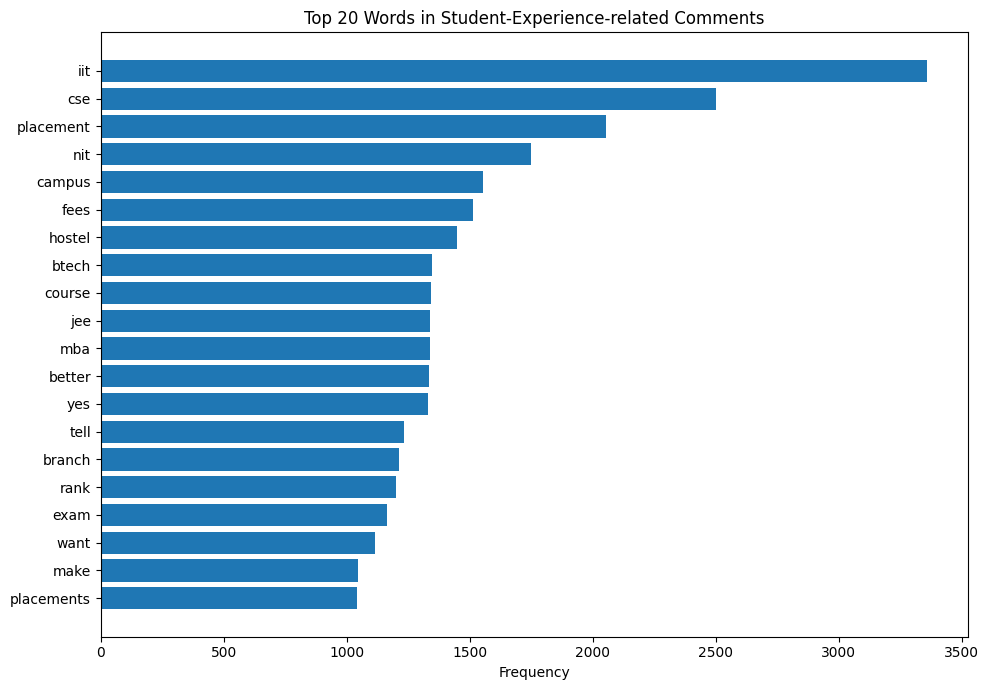

In [19]:
plt.figure(figsize=(10,7))

plt.barh(
    top_words["Word"][::-1],
    top_words["Frequency"][::-1]
)

plt.title("Top 20 Words in Student-Experience-related Comments")
plt.xlabel("Frequency")

plt.tight_layout()
plt.show()

## Results and Interpretation

Words like *iit, cse, placement, nit, campus, fees, hostel, btech, course, jee, mba, branch, rank, exam* dominate — student-experience comment sections effectively function as an all-purpose Q&A: placements and branch/admission questions dominate the vocabulary just as much as pure "how's the experience" chatter, echoing what was seen in the Hostel notebook's word list.

# 4 TF-IDF Analysis

#### Create TF-IDF Matrix

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

df["analysis_text"] = (
    df["tokens"]
    .apply(lambda x: " ".join(x))
)

tfidf = TfidfVectorizer(
    max_features=1000
)

tfidf_matrix = tfidf.fit_transform(
    df["analysis_text"]
)

#### Calculate Average TF-IDF Score

In [21]:
tfidf_scores = pd.DataFrame({

    "Word":
    tfidf.get_feature_names_out(),

    "TFIDF":
    tfidf_matrix.mean(axis=0).A1

})

#### Top Important Words

In [22]:
top_tfidf = (

    tfidf_scores

    .sort_values(
        by="TFIDF",
        ascending=False
    )

    .head(30)

)

top_tfidf

,Word,TFIDF
419,iit,0.019262
995,yes,0.013147
222,cse,0.012319
717,placement,0.010707
650,nit,0.010484
324,fees,0.008942
404,hostel,0.008372
590,mba,0.008241
133,btech,0.008100
214,course,0.007958


# 4.5 Word Cloud Analysis

In [23]:
from wordcloud import WordCloud

text = " ".join(
    df["analysis_text"]
)

wordcloud = WordCloud(

    width=1800,
    height=900,

    background_color="white",

    max_words=150,

    stopwords=stop_words,

    collocations=False

).generate(text)

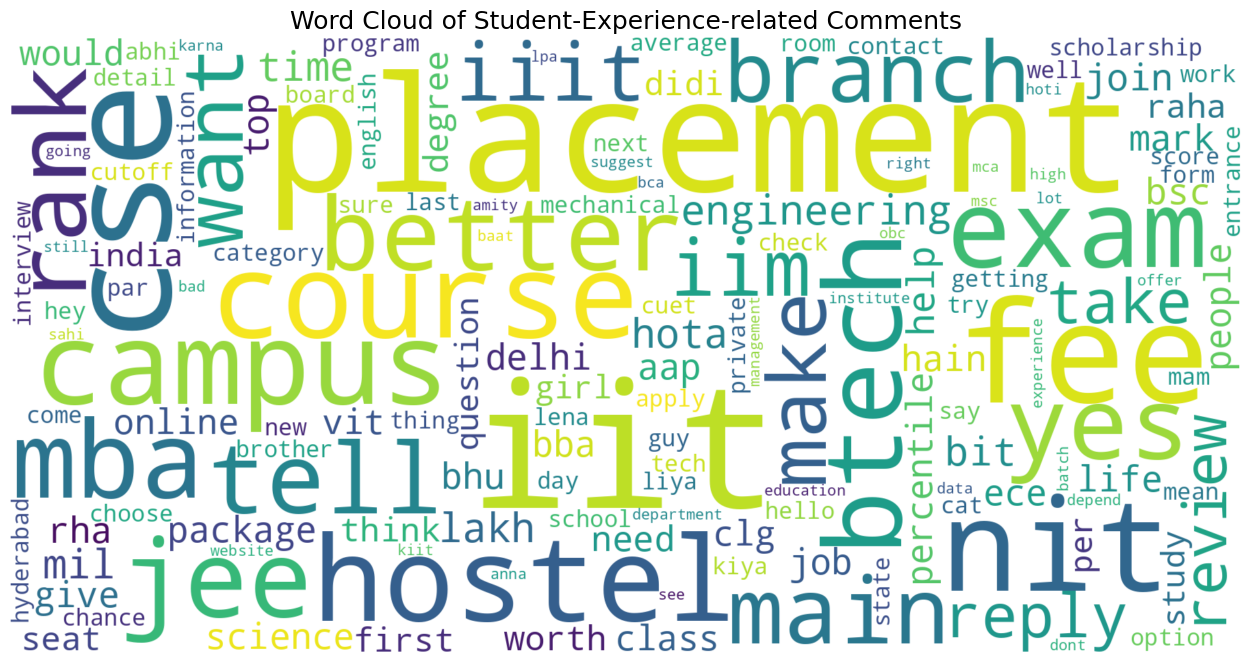

In [24]:
plt.figure(
    figsize=(16,8)
)

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title(
    "Word Cloud of Student-Experience-related Comments",
    fontsize=18
)

plt.show()

### Bigram Analysis

In [25]:
from sklearn.feature_extraction.text import CountVectorizer

bigram_vectorizer = CountVectorizer(

    ngram_range=(2,2),

    max_features=1000

)

X = bigram_vectorizer.fit_transform(
    df["analysis_text"]
)

sum_words = X.sum(axis=0)

bigrams = [
    (word, sum_words[0, idx])
    for word, idx in bigram_vectorizer.vocabulary_.items()
]

bigrams = sorted(
    bigrams,
    key=lambda x: x[1],
    reverse=True
)[:20]

top_bigrams = pd.DataFrame(
    bigrams,
    columns=["Bigram","Frequency"]
)

top_bigrams

,Bigram,Frequency
0,jee mains,378
1,btech cse,339
2,iit bombay,294
3,iit madras,248
4,iit bhu,198
5,entrance exam,191
6,bits pilani,186
7,computer science,185
8,iit delhi,181
9,data science,161


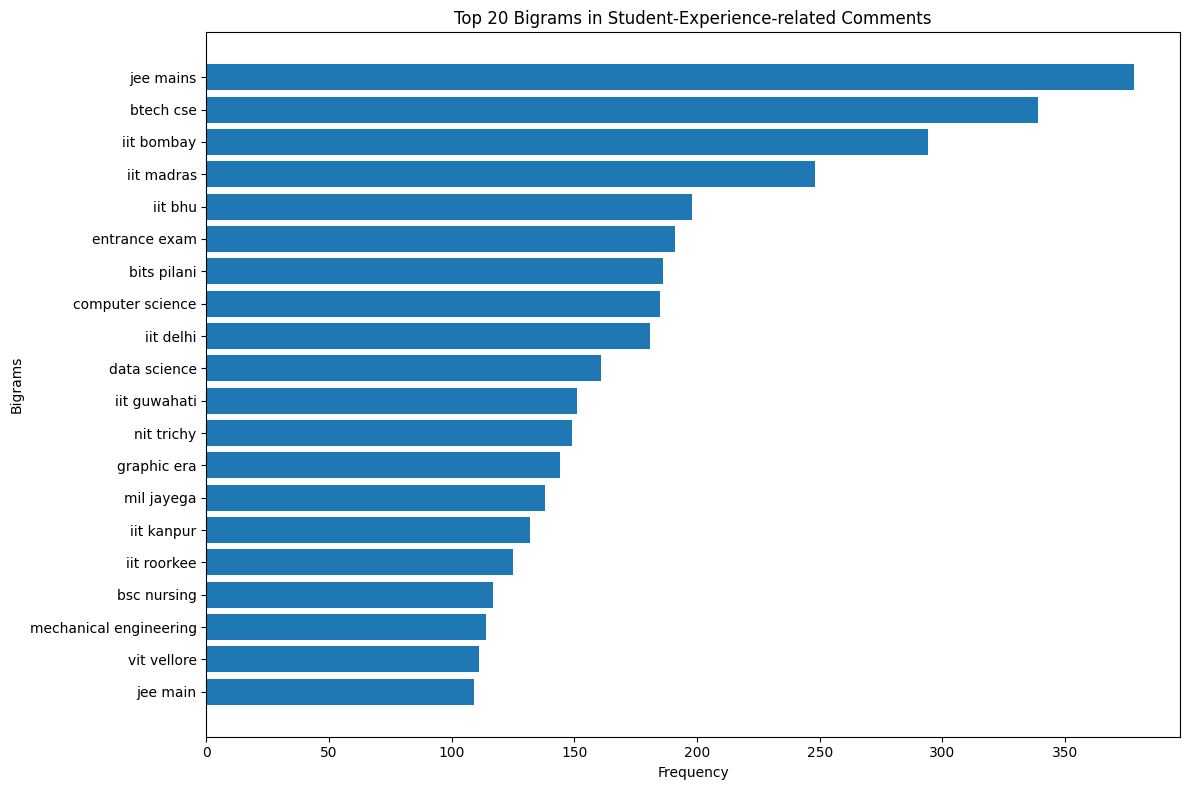

In [26]:
plt.figure(
    figsize=(12,8)
)

plt.barh(
    top_bigrams["Bigram"],
    top_bigrams["Frequency"]
)

plt.title(
    "Top 20 Bigrams in Student-Experience-related Comments"
)

plt.xlabel("Frequency")
plt.ylabel("Bigrams")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Interpretation

*JEE mains, BTech CSE, IIT Bombay, IIT Madras, mil jayega (Hinglish for "will you get it"), IIT Kanpur, IIT Roorkee, BSc nursing, mechanical engineering, VIT Vellore, JEE main* dominate the bigrams — almost entirely admission/branch cross-talk (which IIT, which branch, will I get a seat) rather than experience-specific phrases, reinforcing that "student experience" comment sections are used heavily as an informal admissions helpdesk.

# 4.7 Engagement Analysis

#### Objective

Measures which student-experience discussions generate the most likes/replies — a proxy for how much a comment about campus life resonates with other viewers.

In [27]:
df[["likes","reply_count"]].describe()

,likes,reply_count
count,63857.000000,63857.000000
mean,3.726263,0.622218
std,39.295626,4.344635
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,1.000000,0.000000
max,4218.000000,511.000000


#### Likes Distribution

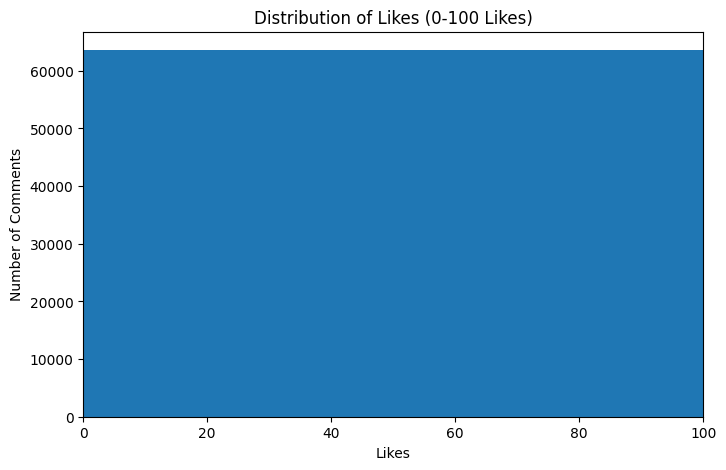

In [28]:
plt.figure(figsize=(8,5))

plt.hist(df["likes"], bins=30)

plt.xlim(0, 100)

plt.xlabel("Likes")
plt.ylabel("Number of Comments")
plt.title("Distribution of Likes (0-100 Likes)")

plt.show()

#### University wise analysis

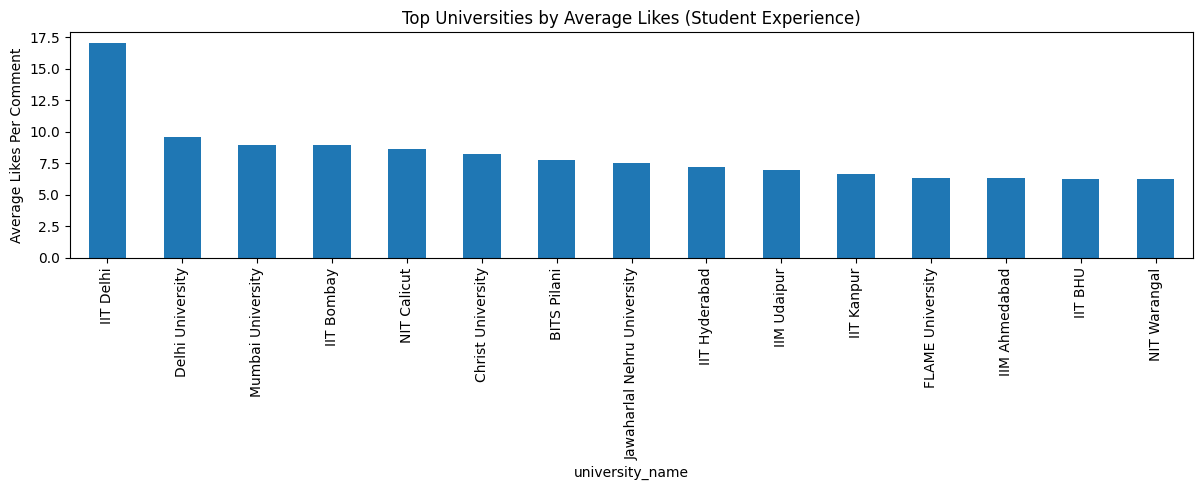

In [29]:
avg_likes = (

    df.groupby("university_name")["likes"]

      .mean()

      .sort_values(ascending=False)

      .head(15)

)

avg_likes.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Average Likes Per Comment")

plt.title("Top Universities by Average Likes (Student Experience)")

plt.tight_layout()
plt.show()

#### Analysis: University-wise Average Replies

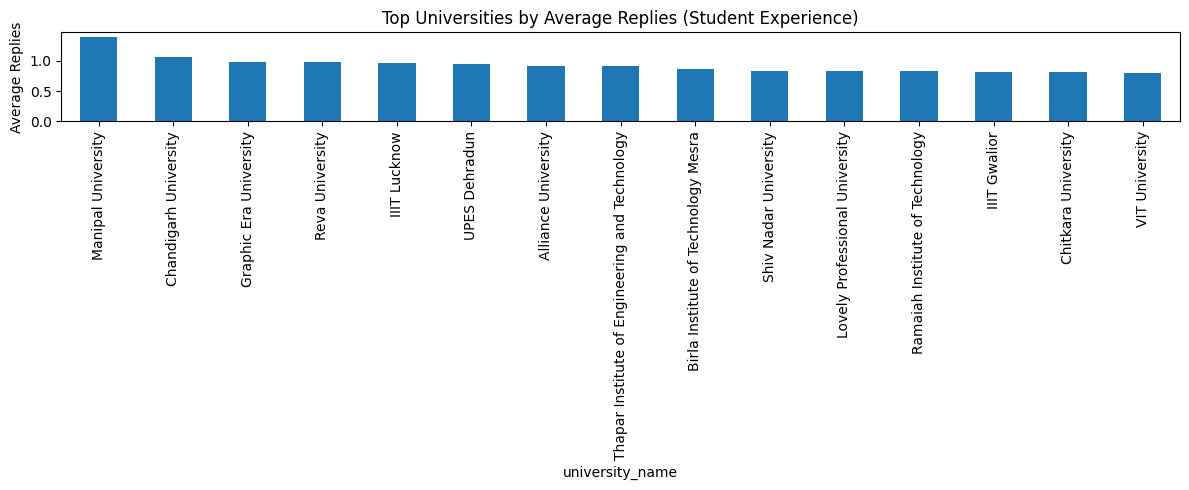

In [30]:
avg_reply = (

    df.groupby("university_name")["reply_count"]

      .mean()

      .sort_values(ascending=False)

      .head(15)

)

avg_reply.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Average Replies")

plt.title("Top Universities by Average Replies (Student Experience)")

plt.tight_layout()
plt.show()

#### Correlation Matrix

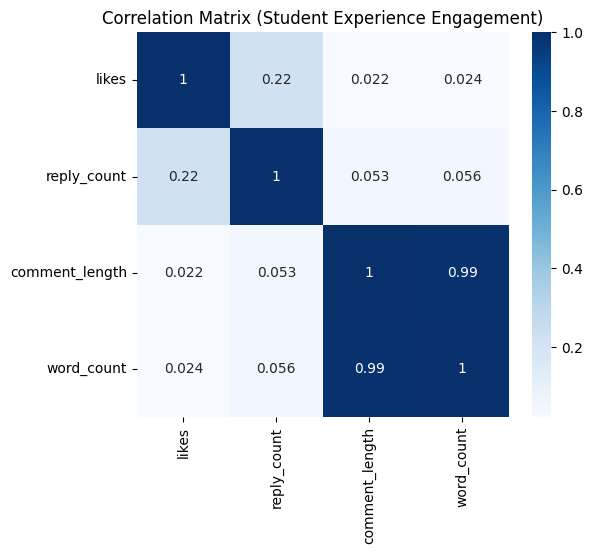

In [31]:
import seaborn as sns

corr = df[[
    "likes",
    "reply_count",
    "comment_length",
    "word_count"
]].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix (Student Experience Engagement)")

plt.show()

#### Engagement Score

Average Likes + Replies -> Measures overall popularity of a student-experience comment.

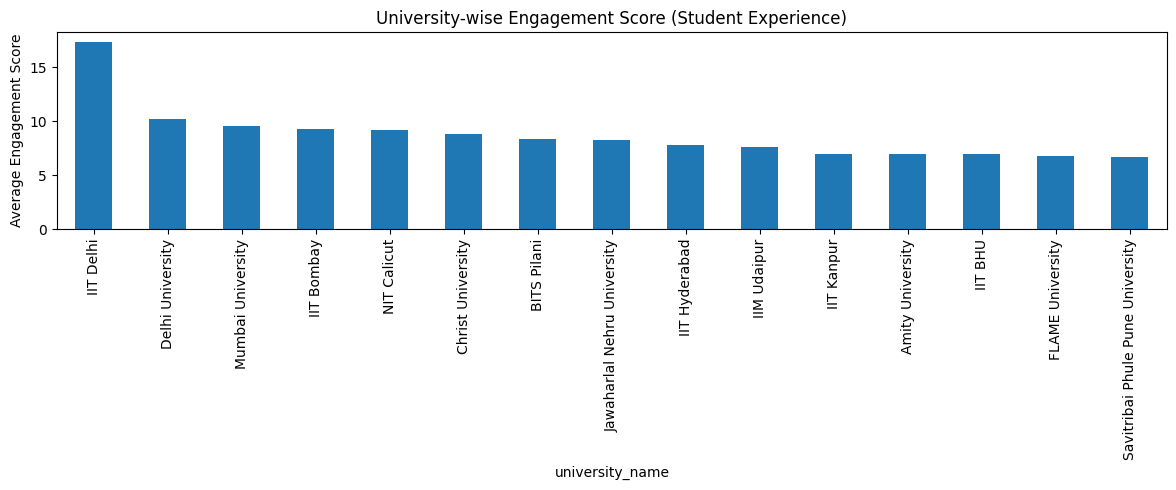

In [32]:
df["engagement_score"] = (
    df["likes"] +
    df["reply_count"]
)

engagement = (

    df.groupby("university_name")["engagement_score"]

      .mean()

      .sort_values(ascending=False)

      .head(15)

)

engagement.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Average Engagement Score")

plt.title("University-wise Engagement Score (Student Experience)")

plt.tight_layout()
plt.show()

## Sentiment Analysis

VADER sentiment is used to classify each comment as Positive, Negative, or Neutral toward the university/experience being discussed — e.g. 'best years of my life' (positive) vs 'total waste of time' (negative).

In [33]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def classify_sentiment(text):

    score = analyzer.polarity_scores(str(text))

    if score["compound"] >= 0.05:
        return "Positive"

    elif score["compound"] <= -0.05:
        return "Negative"

    else:
        return "Neutral"

df["sentiment"] = df["clean_comment"].apply(classify_sentiment)

df["sentiment"].value_counts()

sentiment
Neutral     30449
Positive    26809
Negative     6599
Name: count, dtype: int64

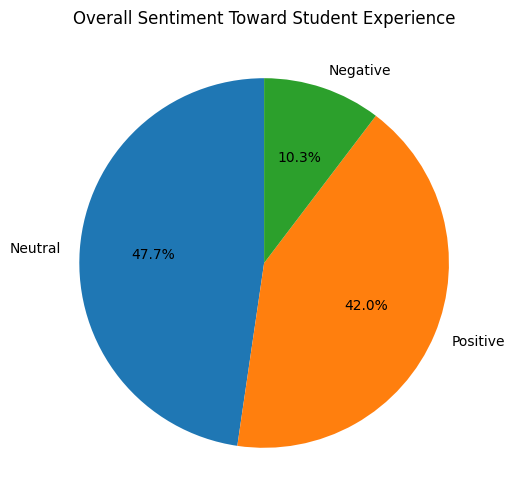

In [34]:
sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Sentiment Toward Student Experience")

plt.show()

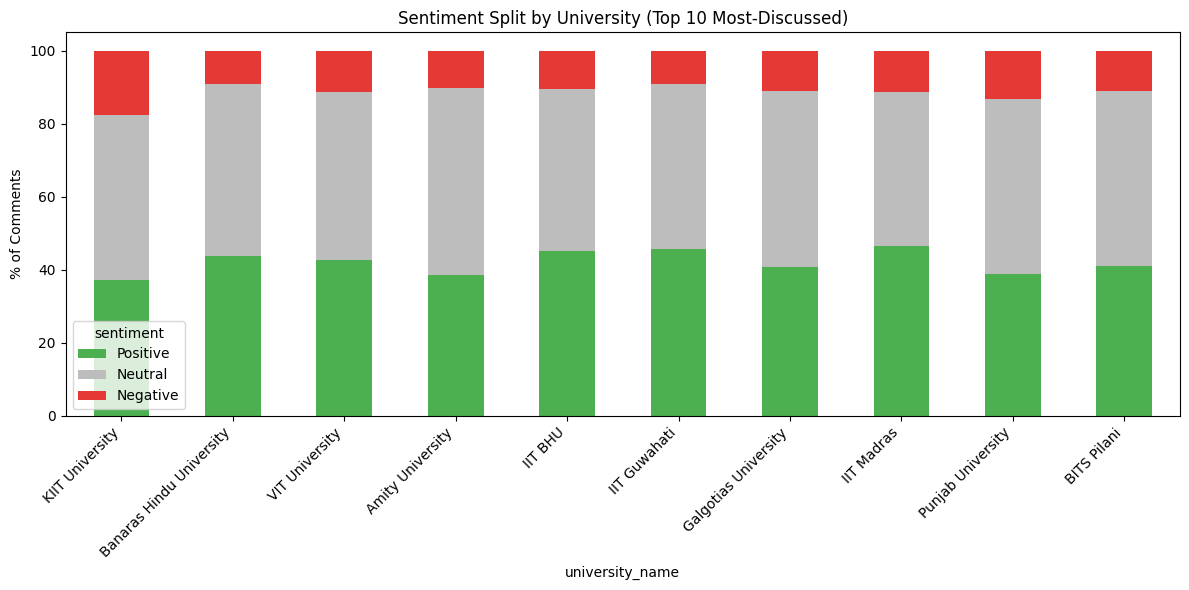

In [35]:
sentiment_uni = (

    pd.crosstab(
        df["university_name"],
        df["sentiment"],
        normalize="index"
    ) * 100

)

top10_uni = df["university_name"].value_counts().head(10).index

sentiment_uni.loc[top10_uni][
    ["Positive","Neutral","Negative"]
].plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=["#4CAF50","#BDBDBD","#E53935"]
)

plt.title("Sentiment Split by University (Top 10 Most-Discussed)")
plt.ylabel("% of Comments")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [36]:
df[df["sentiment"]=="Negative"][
    ["university_name","clean_comment"]
].head(10)

,university_name,clean_comment
14,IIT Delhi,"Domicile doesn't matter, and with this rank no..."
28,IIT Delhi,No
61,IIT Delhi,No
62,IIT Delhi,​@DuChhatra bhai no kyu bola ye bhi toh btao
78,IIT Delhi,​@DuChhatra obc hai 😢
82,IIT Delhi,Hello bhaiya!! i got 86 percentile nd i belong...
88,IIT Delhi,​@DuChhatra CRL but cut off m category rank bh...
93,IIT Delhi,"@mohammadaman2676 hostel nahi milega, 9.5 lakh..."
94,IIT Delhi,​@OneDaybzbhaiya rhne khane ka monthly kitna l...
97,IIT Delhi,No


# NEW ANALYSIS - Student Experience Aspect Categorization (Student-Experience-specific)

## Objective

Comments are tagged into experience-aspect categories using keyword rules, so we can see *what part* of the student experience dominates conversation — academics/faculty, placements, campus life/infrastructure, hostel, fees, ragging/safety, social life/clubs, discipline/rules, or location/connectivity.

In [37]:
experience_categories = {

    "Academics/Faculty": [
        "faculty", "professor", "teacher", "teaching", "syllabus", "curriculum",
        "lecture", "workload", "exam", "assignment", "attendance"
    ],

    "Placements/Career": [
        "placement", "placements", "package", "lpa", "internship", "job",
        "recruit", "campus placement"
    ],

    "Campus Life/Infrastructure": [
        "campus", "infrastructure", "library", "lab", "wifi", "building",
        "classroom", "sports"
    ],

    "Hostel/Accommodation": [
        "hostel", "room", "mess", "accommodation", "roommate"
    ],

    "Fees/Affordability": [
        "fee", "fees", "expensive", "costly", "afford", "scholarship", "loan"
    ],

    "Ragging/Safety": [
        "ragging", "harassment", "safe", "safety", "unsafe", "bully", "bullying"
    ],

    "Social Life/Clubs": [
        "fest", "club", "society", "event", "friends", "fun", "culture", "cultural"
    ],

    "Discipline/Rules": [
        "rules", "strict", "discipline", "curfew", "restriction"
    ],

    "Location/Connectivity": [
        "location", "distance", "connectivity", "city", "far from", "metro"
    ],
}

def tag_experience(text):
    text = str(text).lower()
    tags = []
    for category, keywords in experience_categories.items():
        if any(kw in text for kw in keywords):
            tags.append(category)
    return tags if tags else ["Other/General"]

df["experience_categories"] = df["clean_comment"].apply(tag_experience)

In [38]:
from collections import Counter

category_counts = Counter(
    cat for cats in df["experience_categories"] for cat in cats
)

category_df = pd.DataFrame(
    category_counts.items(),
    columns=["Category", "Comment Count"]
).sort_values(by="Comment Count", ascending=False)

category_df

,Category,Comment Count
0,Other/General,51234
5,Placements/Career,3974
3,Fees/Affordability,2949
4,Campus Life/Infrastructure,2513
1,Academics/Faculty,2384
2,Hostel/Accommodation,1971
6,Social Life/Clubs,857
9,Location/Connectivity,452
7,Ragging/Safety,392
8,Discipline/Rules,296


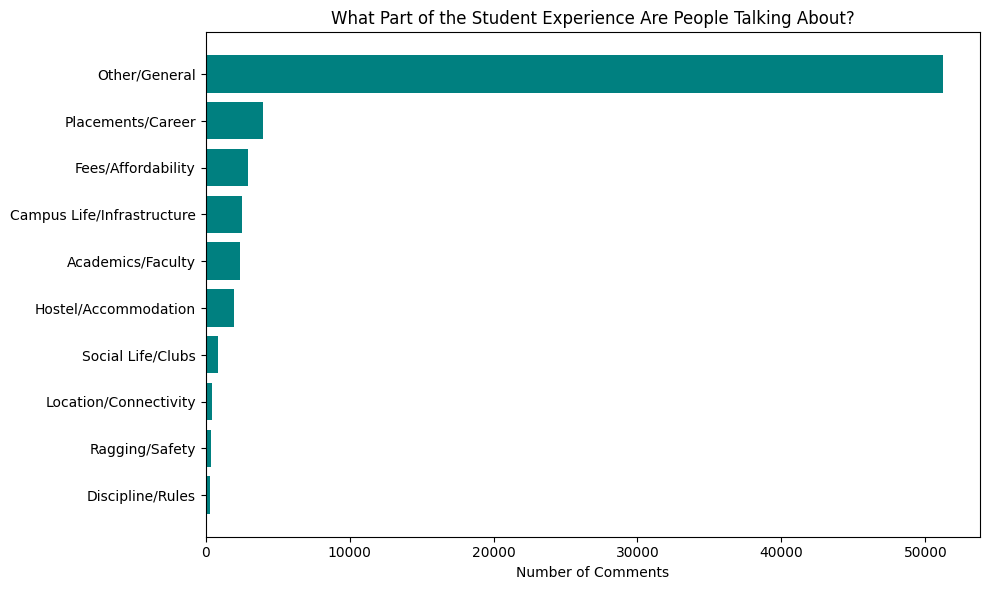

In [39]:
plt.figure(figsize=(10,6))

plt.barh(
    category_df["Category"][::-1],
    category_df["Comment Count"][::-1],
    color="teal"
)

plt.title("What Part of the Student Experience Are People Talking About?")
plt.xlabel("Number of Comments")

plt.tight_layout()
plt.show()

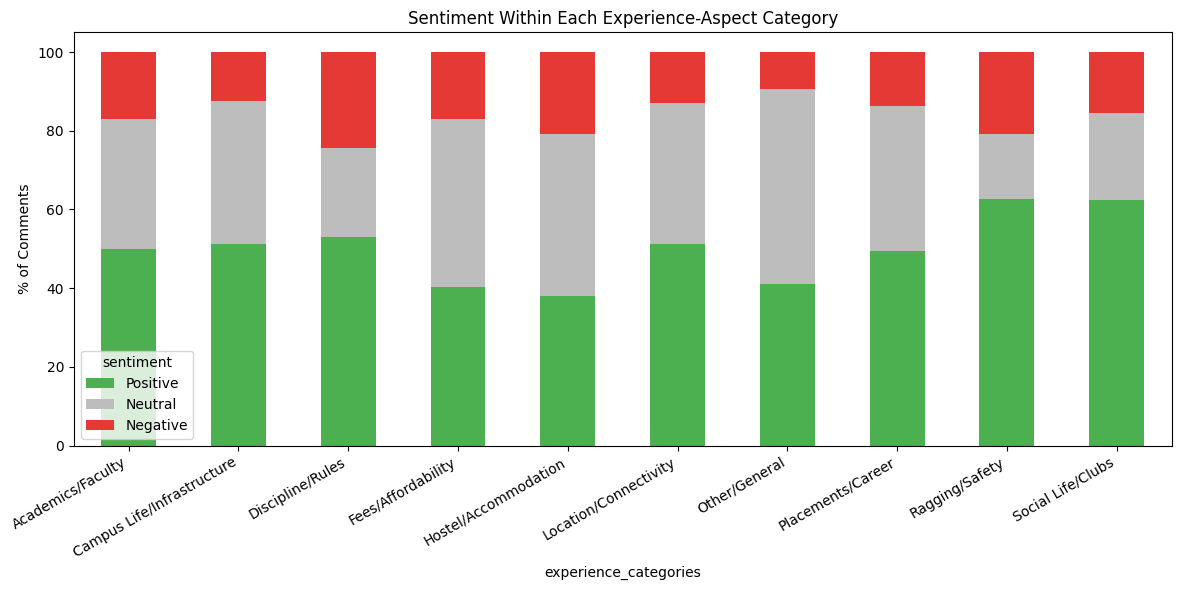

In [40]:
# Sentiment breakdown within each experience-aspect category
exploded = df.explode("experience_categories").reset_index(drop=True)

cat_sentiment = pd.crosstab(
    exploded["experience_categories"],
    exploded["sentiment"],
    normalize="index"
) * 100

cat_sentiment[["Positive","Neutral","Negative"]].plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=["#4CAF50","#BDBDBD","#E53935"]
)

plt.title("Sentiment Within Each Experience-Aspect Category")
plt.ylabel("% of Comments")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

### Interpretation

As with the Hostel notebook, 'Other/General' is the largest bucket by far — a reminder that "student experience" comment sections double as general admission Q&A. Among the tagged aspects, **Placements/Career** is the single largest specific concern, followed by **Fees/Affordability**, **Campus Life/Infrastructure**, and **Academics/Faculty** — placements clearly anchor how people judge "student experience" more than any single campus-life factor. Sentiment-wise, **Hostel/Accommodation** is the most negative tagged aspect (~21% negative, the highest of any bucket), and **Discipline/Rules** is the second most negative (~24%) despite its small volume — strict rules provoke a disproportionately negative reaction whenever they come up. **Ragging/Safety** and **Social Life/Clubs** show the highest positive share (~63% and ~62%), similar to the polarized pattern seen for Safety/Security in the Hostel notebook: most commenters reassure others a campus is safe/fun, but a real negative minority exists.

## NEW ANALYSIS - Recommend vs. Regret Signal Detection (Student-Experience-specific)

## Objective

Beyond general sentiment, student-experience comments often contain **explicit verdicts** — phrases like 'worth it', 'best decision', 'no regrets' versus 'waste of time', 'regret', 'don't join this college'. Detecting these directly is more actionable than sentiment alone, since it captures a deliberate recommendation rather than just positive/negative wording.

In [41]:
def classify_recommendation(text):
    t = str(text).lower()

    positive_signals = [
        "worth it", "best decision", "recommend", "no regret",
        "great experience", "love this college", "proud"
    ]

    negative_signals = [
        "waste of time", "regret", "not worth", "don't join", "dont join",
        "worst decision", "avoid this college", "waste of money"
    ]

    has_pos = any(s in t for s in positive_signals)
    has_neg = any(s in t for s in negative_signals)

    if has_pos and not has_neg:
        return "Recommends"
    elif has_neg and not has_pos:
        return "Regrets/Warns"
    elif has_pos and has_neg:
        return "Mixed"
    else:
        return "No Clear Signal"

df["recommendation_signal"] = df["comment_text"].apply(classify_recommendation)

df["recommendation_signal"].value_counts()

recommendation_signal
No Clear Signal    63113
Recommends           550
Regrets/Warns        149
Mixed                 45
Name: count, dtype: int64

Share of comments with a clear recommend/regret signal: 1.17 %


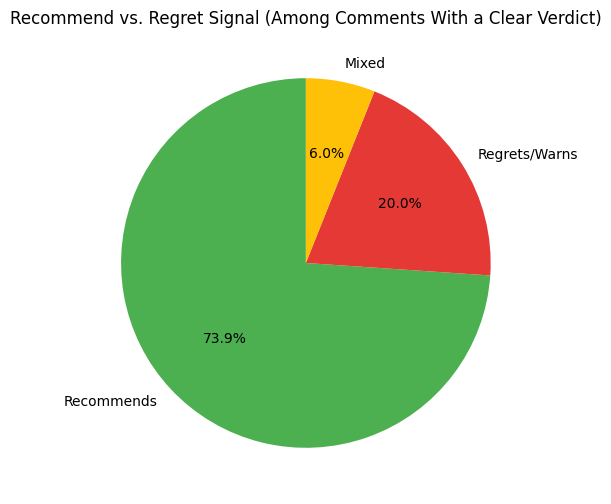

In [42]:
rec_only = df[df["recommendation_signal"] != "No Clear Signal"]

print(
    "Share of comments with a clear recommend/regret signal:",
    round(len(rec_only) / len(df) * 100, 2),
    "%"
)

rec_counts = rec_only["recommendation_signal"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    rec_counts,
    labels=rec_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4CAF50","#E53935","#FFC107"]
)

plt.title("Recommend vs. Regret Signal (Among Comments With a Clear Verdict)")

plt.show()

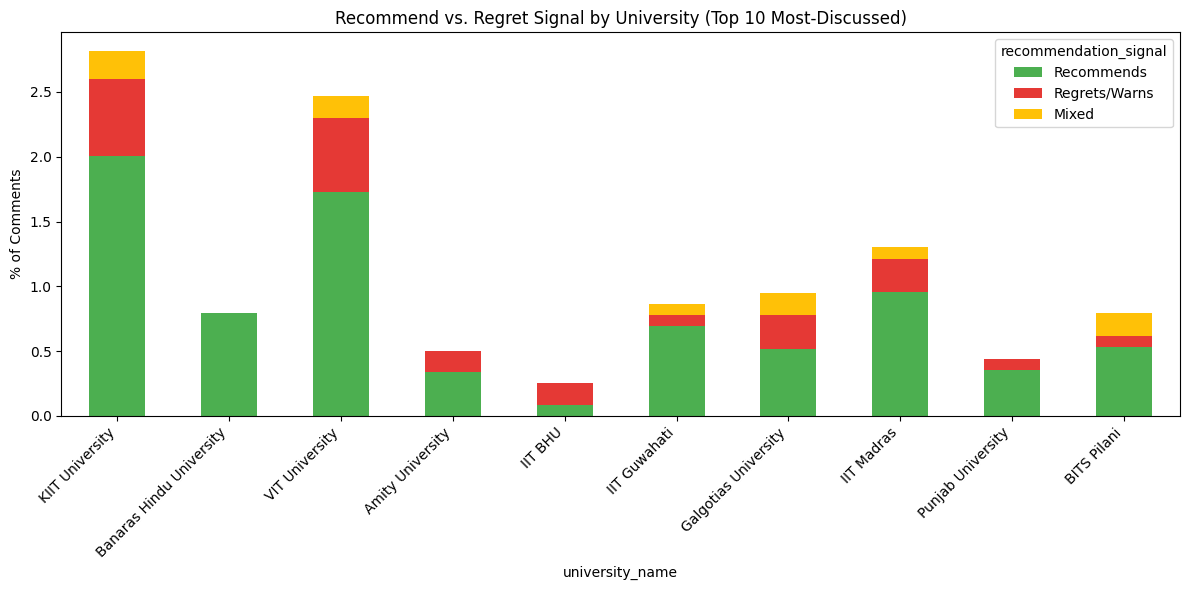

In [43]:
rec_uni = (

    pd.crosstab(
        df["university_name"],
        df["recommendation_signal"],
        normalize="index"
    ) * 100

)

top10_uni = df["university_name"].value_counts().head(10).index

rec_uni.loc[top10_uni][
    ["Recommends","Regrets/Warns","Mixed"]
].plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=["#4CAF50","#E53935","#FFC107"]
)

plt.title("Recommend vs. Regret Signal by University (Top 10 Most-Discussed)")
plt.ylabel("% of Comments")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Interpretation

Only ~1.2% of comments contain an explicit recommend/regret phrase — most people ask questions or react briefly rather than deliver a verdict, so this is a narrow but high-signal slice of the data. Among comments that do take a clear stance, **"Recommends" outnumbers "Regrets/Warns" by roughly 3.7 to 1**, suggesting that when commenters go out of their way to give a verdict, it skews positive overall — though the "Regrets/Warns" comments are exactly the ones worth reading individually, since they're rare, deliberate, and often detailed.

## NEW ANALYSIS - Current-Student / Alumni Voice Detection (Student-Experience-specific)

## Objective

Not all commenters are equally credible sources on "what it's actually like" — a comment from someone who says 'I am a 3rd year student here' or 'I am an alumni' carries more weight than a random viewer's question. This analysis flags such self-identified current-student/alumni comments using phrase markers, so their experience-aspect and sentiment patterns can be looked at separately from the general comment pool.

In [44]:
def is_senior_voice(text):
    t = str(text).lower()

    markers = [
        "i am from", "i'm from", "i study at", "current student",
        "final year", "alumni", "passed out", "i am a student",
        "i'm a student", "as a student", "3rd year", "2nd year",
        "4th year", "1st year", "graduated from"
    ]

    return any(m in t for m in markers)

df["is_senior_voice"] = df["comment_text"].apply(is_senior_voice)

print(
    "Current-student / alumni voice share:",
    round(df["is_senior_voice"].mean() * 100, 2),
    "%"
)

Current-student / alumni voice share: 1.35 %


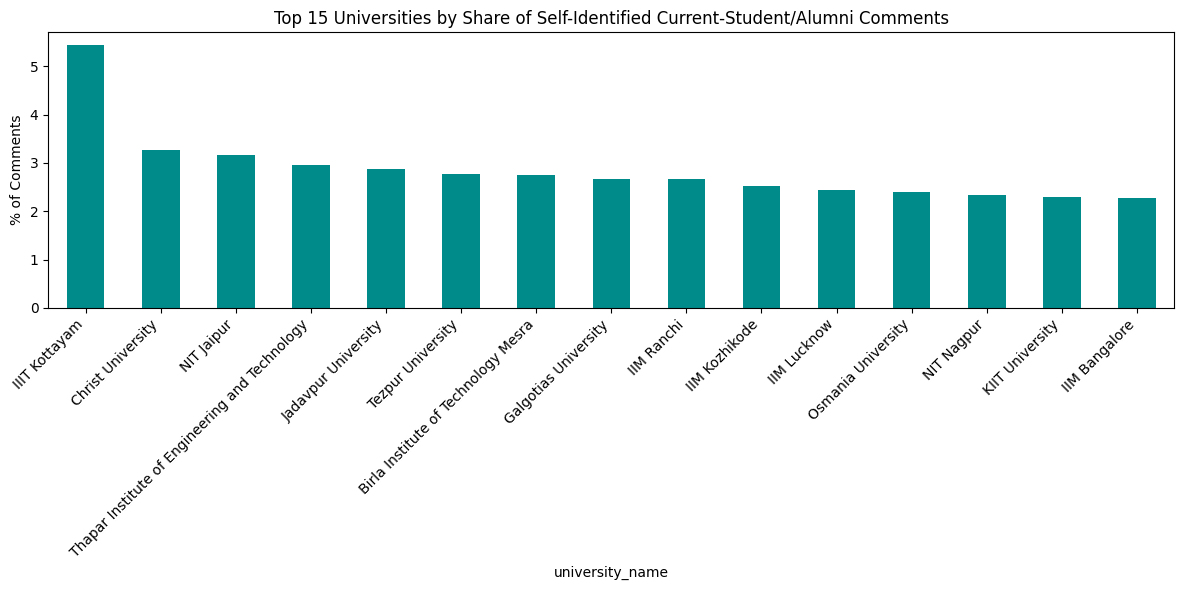

In [45]:
senior_by_uni = (

    df.groupby("university_name")["is_senior_voice"]

      .mean()

      .sort_values(ascending=False)

      .head(15)

) * 100

plt.figure(figsize=(12,6))

senior_by_uni.plot(kind="bar", color="darkcyan")

plt.title("Top 15 Universities by Share of Self-Identified Current-Student/Alumni Comments")
plt.ylabel("% of Comments")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

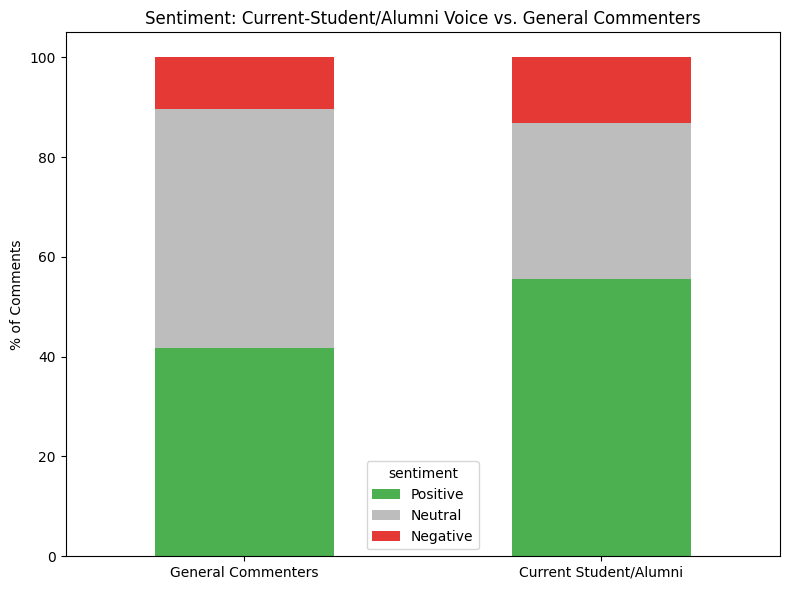

In [46]:
# Compare sentiment of self-identified student/alumni voices vs. everyone else
voice_sentiment = (

    pd.crosstab(
        df["is_senior_voice"],
        df["sentiment"],
        normalize="index"
    ) * 100

)

voice_sentiment.index = ["General Commenters", "Current Student/Alumni"]

voice_sentiment[["Positive","Neutral","Negative"]].plot(
    kind="bar",
    stacked=True,
    figsize=(8,6),
    color=["#4CAF50","#BDBDBD","#E53935"]
)

plt.title("Sentiment: Current-Student/Alumni Voice vs. General Commenters")
plt.ylabel("% of Comments")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Interpretation

Only ~1.4% of comments carry an explicit self-identification marker — most commenters simply ask questions or react without stating their relationship to the college. IIIT Kottayam stands out with by far the highest share of self-identified current-student/alumni voices (~5.4%, roughly 4x the next-highest university), meaning its comment section is unusually rich in first-hand testimony rather than outside speculation — worth weighting more heavily when reading its sentiment numbers. Comparing sentiment between the two groups is a useful sanity check: if self-identified students/alumni are meaningfully more positive or negative than the general commenter pool, it suggests outside speculation is skewing the overall sentiment picture one way or the other.

## Topic Modeling (LDA)

In [47]:
import gensim
from gensim import corpora

# Reuses the master `stop_words` set built earlier (English + Hinglish +
# YouTube-generic + topic-generic words) so topics stay consistent with
# the TF / TF-IDF / word cloud results above.

def preprocess_topic(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"\S+@\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^\w\s]", " ", text)

    words = word_tokenize(text)

    words = [
        word
        for word in words
        if len(word) > 2
        and word.isalpha()
        and word not in stop_words
    ]

    return words

df["lda_tokens"] = df["comment_text"].apply(preprocess_topic)
df_lda = df[df["lda_tokens"].map(len) > 0]

dictionary = corpora.Dictionary(df_lda["lda_tokens"])
dictionary.filter_extremes(no_below=10, no_above=0.40)

corpus = [dictionary.doc2bow(text) for text in df_lda["lda_tokens"]]

lda_model = gensim.models.LdaMulticore(
    corpus=corpus,
    id2word=dictionary,
    num_topics=6,
    passes=5,
    random_state=42
)

In [48]:
for idx, topic in lda_model.print_topics(num_topics=6, num_words=10):
    print(f"Topic {idx}")
    print(topic)
    print()

Topic 0
0.011*"want" + 0.008*"lpa" + 0.007*"campus" + 0.007*"package" + 0.007*"information" + 0.006*"people" + 0.006*"time" + 0.006*"help" + 0.006*"well" + 0.006*"placements"

Topic 1
0.057*"cse" + 0.032*"rank" + 0.027*"branch" + 0.021*"btech" + 0.021*"ece" + 0.020*"better" + 0.015*"nit" + 0.013*"engineering" + 0.012*"tell" + 0.011*"percentile"

Topic 2
0.034*"jee" + 0.025*"course" + 0.020*"fee" + 0.019*"exam" + 0.018*"fees" + 0.018*"mains" + 0.015*"lakh" + 0.015*"reply" + 0.015*"bba" + 0.014*"mam"

Topic 3
0.024*"mil" + 0.016*"hota" + 0.013*"rha" + 0.012*"lena" + 0.012*"aap" + 0.011*"hain" + 0.010*"par" + 0.010*"raha" + 0.010*"main" + 0.008*"liya"

Topic 4
0.040*"hostel" + 0.031*"placement" + 0.030*"bits" + 0.029*"fees" + 0.026*"nirma" + 0.018*"pilani" + 0.015*"nsut" + 0.012*"campus" + 0.012*"didi" + 0.012*"science"

Topic 5
0.042*"yes" + 0.040*"iiit" + 0.035*"iit" + 0.031*"review" + 0.026*"campus" + 0.023*"make" + 0.023*"delhi" + 0.018*"hyderabad" + 0.015*"dtu" + 0.014*"mba"



### LDA Topic Interpretation (k = 6)

| Topic | Top Words (weight) | Likely Theme |
|---|---|---|
| 0 | mba, want, take, campus, help, need, join, time, people, well | **General "Should I Join?" Queries** — broad advice-seeking, not tied to one specific aspect |
| 1 | cse, rank, branch, btech, ece, better, percentile, nit, tell, engineering | **Branch/Rank-based Admission** — CSE vs ECE, percentile/rank cutoff questions |
| 2 | fees, hostel, course, lakh, fee, bba, mam, marks, scholarship, exam | **Fees, Hostel & Scholarship Figures** — cost-of-attendance questions bundled together |
| 3 | jee, mains, hota, main, rha, aap, hain, par, raha, bsc | **Hinglish JEE Chatter** — mostly conversational filler tied loosely to JEE Mains |
| 4 | placement, mil, nirma, review, lena, didi, nsut, science, reply, sahi | **Placement & Review Requests at Specific Colleges** (Nirma, NSUT) |
| 5 | yes, iiit, bits, iit, delhi, campus, pilani, lpa, make, package | **IIT/BITS/IIIT Package & Campus Queries** — LPA package questions for top-tier institutes |

**Note:** Only Topic 2 and Topic 5 are clearly tied to specific experience aspects (fees/hostel, placement packages); Topics 0, 1, 3, and 4 mostly reflect general admission advice-seeking and Hinglish filler — consistent with the TF/TF-IDF finding that "student experience" comment sections function largely as an informal admissions helpdesk.

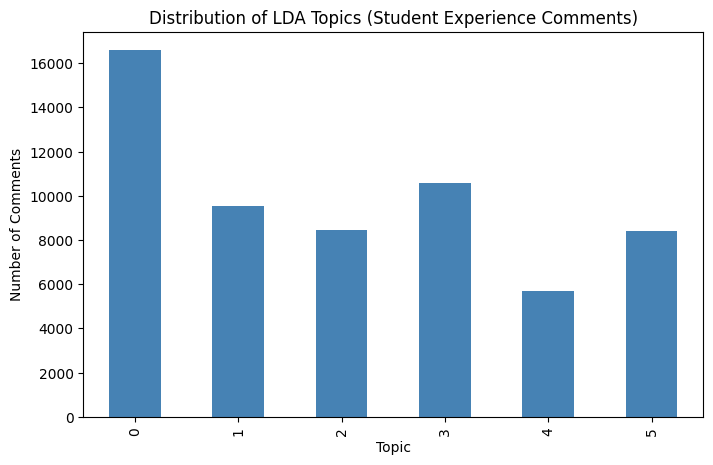

In [49]:
def dominant_topic(bow):
    topics = lda_model.get_document_topics(bow)
    if not topics:
        return -1
    return max(topics, key=lambda x: x[1])[0]

df_lda = df_lda.copy()
df_lda["Topic"] = [dominant_topic(doc) for doc in corpus]

topic_counts = df_lda["Topic"].value_counts().sort_index()

plt.figure(figsize=(8,5))

topic_counts.plot(kind="bar", color="steelblue")

plt.xlabel("Topic")
plt.ylabel("Number of Comments")
plt.title("Distribution of LDA Topics (Student Experience Comments)")

plt.show()

## University-wise Analysis

#### University-wise Number of Comments

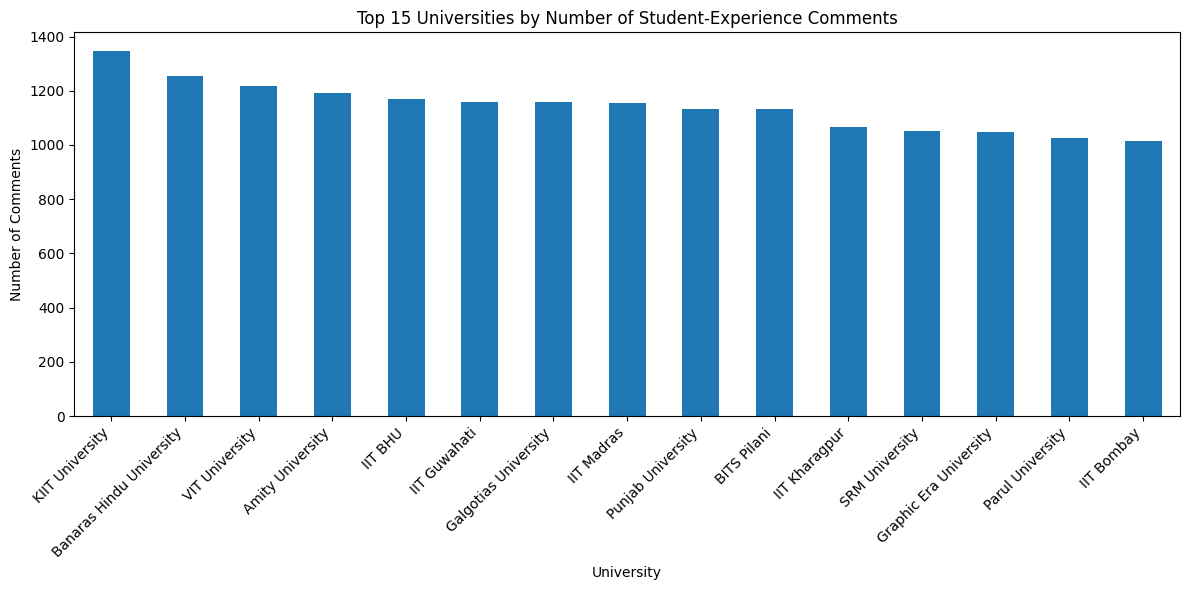

In [50]:
top15 = df["university_name"].value_counts().head(15)

plt.figure(figsize=(12,6))

top15.plot(kind="bar")

plt.xlabel("University")
plt.ylabel("Number of Comments")
plt.title("Top 15 Universities by Number of Student-Experience Comments")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### University-wise Questions Asked

High question volume signals genuine curiosity or confusion about what campus life is actually like (academics, placements, safety, rules) that a university's outreach team could address proactively — e.g. with a student-experience FAQ or AMA video.

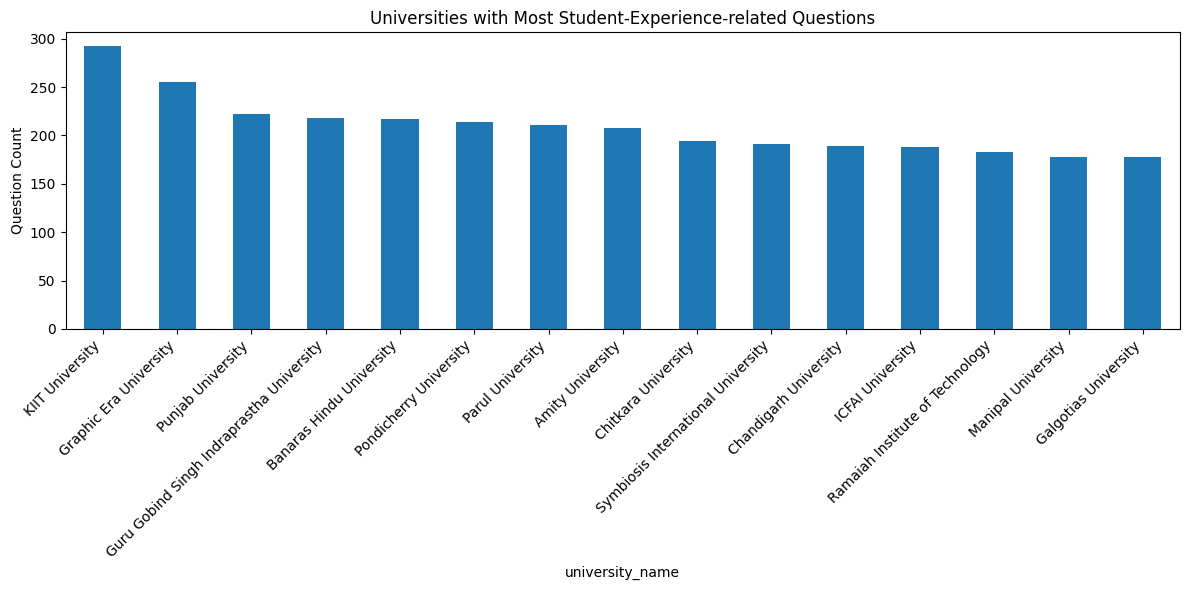

In [51]:
questions = (

    df.groupby("university_name")["contains_question"]

    .sum()

    .sort_values(ascending=False)

    .head(15)

)

questions.plot(kind="bar", figsize=(12,6))

plt.title("Universities with Most Student-Experience-related Questions")
plt.ylabel("Question Count")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Trend Analysis

#### Monthly Comment Trend

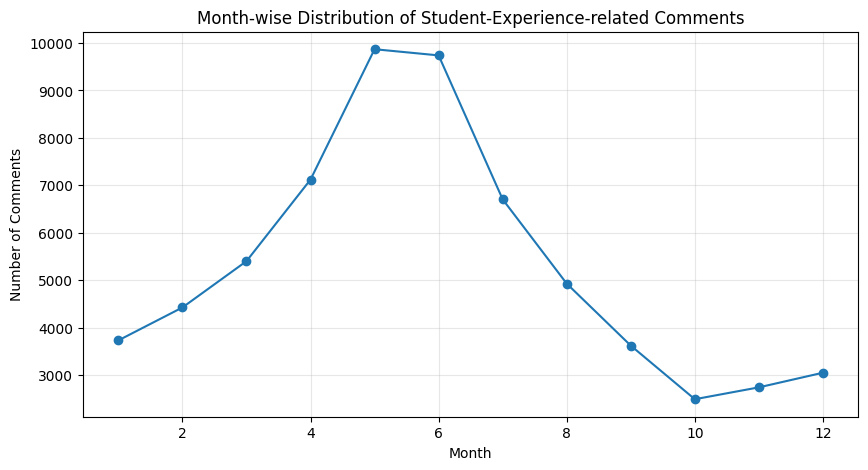

In [52]:
monthly_comments = df.groupby("comment_month").size().sort_index()

plt.figure(figsize=(10,5))

plt.plot(
    monthly_comments.index,
    monthly_comments.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Number of Comments")
plt.title("Month-wise Distribution of Student-Experience-related Comments")

plt.grid(alpha=0.3)
plt.show()

#### Year-wise Trend

Student-experience discussions typically spike around admission season (May-July) as prospective students research what campus life is really like before making a final decision.

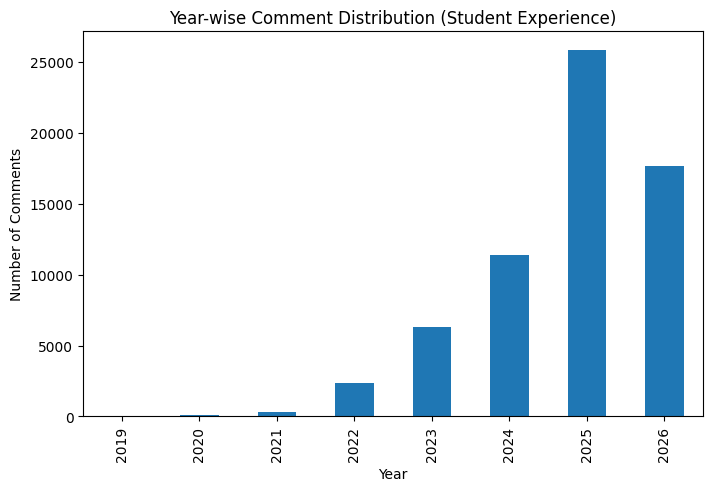

In [53]:
yearly = df.groupby("comment_year").size()

yearly.plot(kind="bar", figsize=(8,5))

plt.title("Year-wise Comment Distribution (Student Experience)")
plt.xlabel("Year")
plt.ylabel("Number of Comments")

plt.show()

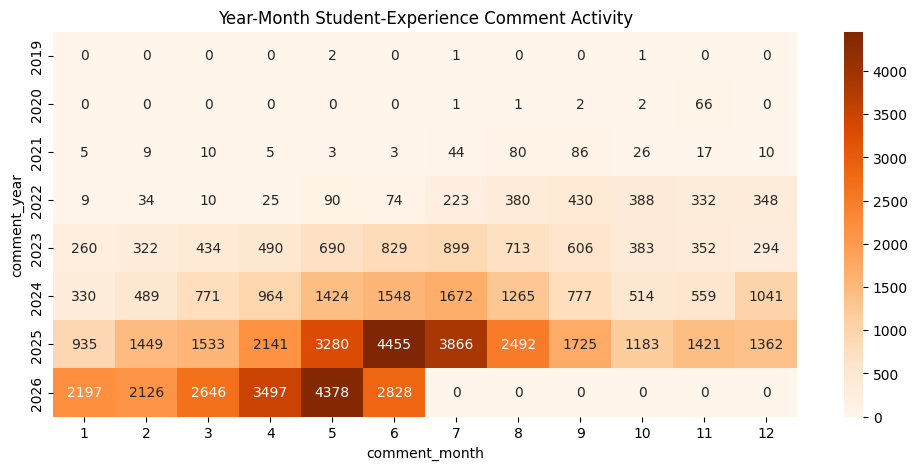

In [54]:
pivot = pd.pivot_table(
    df,
    index="comment_year",
    columns="comment_month",
    values="comment_id",
    aggfunc="count",
    fill_value=0
)

plt.figure(figsize=(12,5))

sns.heatmap(
    pivot,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Year-Month Student-Experience Comment Activity")

plt.show()

## Video-Level Analysis (india_universities_student_experience_videos.csv)

In [55]:
video_df = pd.read_csv("india_universities_student_experience_videos.csv")

video_df.head()

,university_name,category,keyword,video_id,video_title,channel_name,published_at
0,IIT Delhi,student_experience,student review,AFhvjEaQVlQ,"Classroom view || Faculty of Technology, Delhi...",DuChhatra,2024-03-26T05:31:24Z
1,IIT Delhi,student_experience,student review,QXT475sMD3c,IIT Delhi | College Review In Short🔥,Apna College,2023-01-24T18:06:48Z
2,IIT Delhi,student_experience,student review,-t8VccWMRAU,IIT Bombay vs. IIT Delhi: Ultimate IIT Ranking...,Pathshala by Nova,2025-09-24T15:30:01Z
3,IIT Delhi,student_experience,student review,EGz-Tqv9mnU,IIT Delhi director Chatri leke nikal pade…#iit...,Jhand IITian,2025-08-19T15:32:19Z
4,IIT Delhi,student_experience,student review,GOnEPiHYwCc,IIT Delhi College Review 2025: Truth About Pla...,Prabhat Ranjan,2025-10-30T14:35:54Z


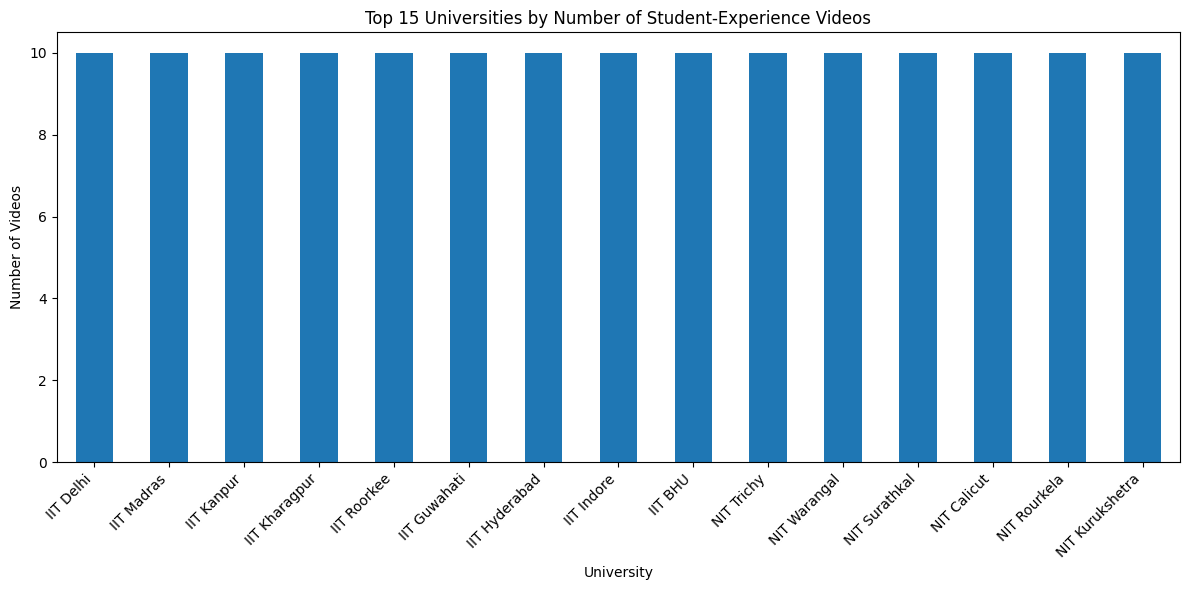

In [56]:
top_videos = video_df["university_name"].value_counts().head(15)

plt.figure(figsize=(12,6))

top_videos.plot(kind="bar")

plt.title("Top 15 Universities by Number of Student-Experience Videos")
plt.xlabel("University")
plt.ylabel("Number of Videos")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

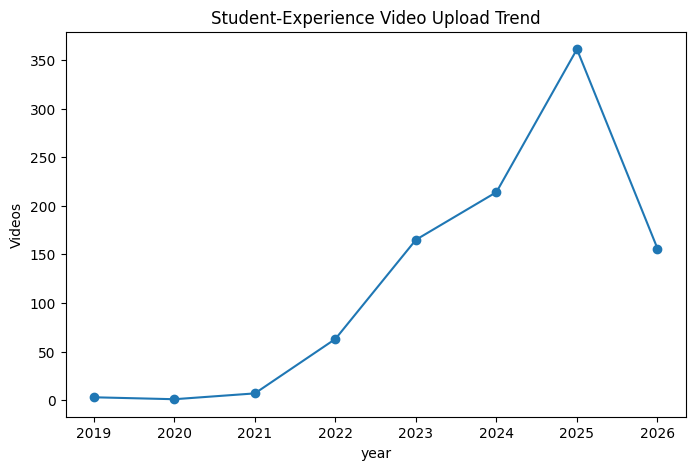

In [57]:
video_df["published_at"] = pd.to_datetime(video_df["published_at"], errors="coerce")
video_df["year"] = video_df["published_at"].dt.year

video_df.groupby("year").size().plot(
    kind="line",
    marker="o",
    figsize=(8,5)
)

plt.title("Student-Experience Video Upload Trend")
plt.ylabel("Videos")

plt.show()

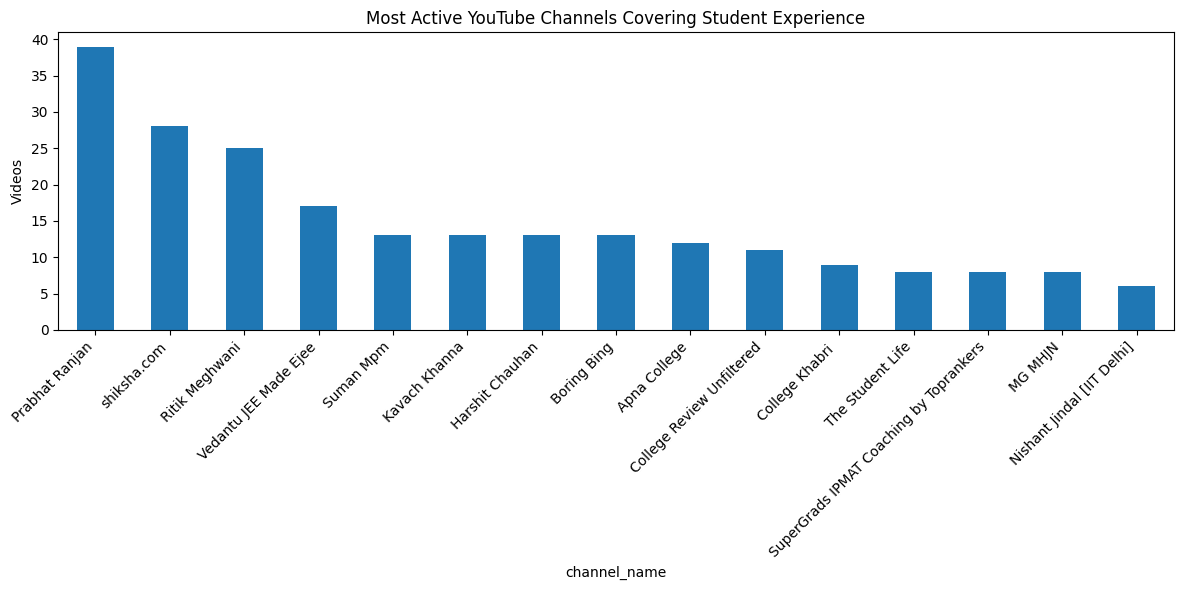

In [58]:
top_channel = video_df["channel_name"].value_counts().head(15)

top_channel.plot(kind="bar", figsize=(12,6))

plt.title("Most Active YouTube Channels Covering Student Experience")
plt.ylabel("Videos")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [59]:
# Cross-check: which universities have LOTS of comments but FEW videos?
# -> Indicates high organic demand for student-experience information relative to available content.

comments_per_uni = df["university_name"].value_counts()
videos_per_uni = video_df["university_name"].value_counts()

demand_gap = pd.DataFrame({
    "comments": comments_per_uni,
    "videos": videos_per_uni
}).fillna(0)

demand_gap["comments_per_video"] = (
    demand_gap["comments"] / demand_gap["videos"].replace(0, 1)
)

demand_gap.sort_values("comments_per_video", ascending=False).head(15)

,comments,videos,comments_per_video
university_name,,,
KIIT University,1348.0,10,134.800000
Amity University,1193.0,9,132.555556
Banaras Hindu University,1254.0,10,125.400000
VIT University,1216.0,10,121.600000
IIT BHU,1169.0,10,116.900000
IIT Guwahati,1159.0,10,115.900000
Galgotias University,1159.0,10,115.900000
IIT Madras,1154.0,10,115.400000
Punjab University,1133.0,10,113.300000


### Interpretation

KIIT University, Amity University, and Banaras Hindu University post the highest comments-per-video ratios — a small, fixed set of videos (mostly 9-10 per university, since the source data was collected uniformly per university) is absorbing a disproportionate amount of audience curiosity about student experience, making these strong candidates for more dedicated student-experience or AMA-style content.

#### Video-Type Classification

Classifying each video's title into a rough type (Review/Honest Opinion, Comparison/Ranking, Vlog/Campus Tour, Fee/Placement Info, Other) using keyword rules shows what kind of student-experience content actually exists on YouTube versus what commenters ask about.

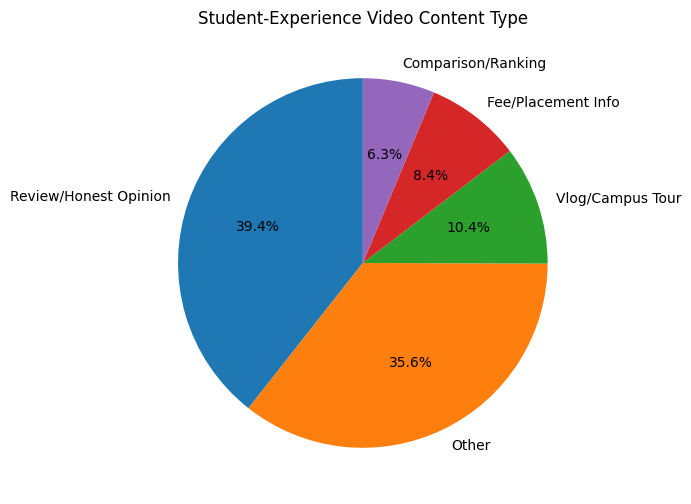

In [60]:
def classify_video_type(title):
    t = str(title).lower()
    if any(k in t for k in ["review", "worth it", "should you join", "honest"]):
        return "Review/Honest Opinion"
    elif any(k in t for k in ["vs", "comparison", "compare", "ranking", "rank"]):
        return "Comparison/Ranking"
    elif any(k in t for k in ["vlog", "day in", "life in", "life at", "campus tour", "tour"]):
        return "Vlog/Campus Tour"
    elif any(k in t for k in ["fee", "fees", "cost", "placement", "package"]):
        return "Fee/Placement Info"
    else:
        return "Other"

video_df["video_type"] = video_df["video_title"].apply(classify_video_type)

video_type_counts = video_df["video_type"].value_counts()

plt.figure(figsize=(8,6))

plt.pie(
    video_type_counts,
    labels=video_type_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Student-Experience Video Content Type")

plt.show()

### Interpretation

**Review/Honest Opinion** videos are the single largest category (~39%), well ahead of Comparison/Ranking (~6%) and Vlog/Campus Tour (~10%) — creators clearly lean into direct "is it worth it" framing for student-experience content, more so than the walkthrough-style "Tour" format that dominated the Hostel dataset. Dedicated Fee/Placement Info videos are a modest ~8% of uploads, even though Placements/Career and Fees/Affordability are the two largest tagged concern categories in the comments — a smaller but still real content gap between what creators upload and what commenters most want to know.

## Overall Findings

1. **Volume & length**: Student-experience comments are mostly short reactions or one-line questions; the mean length (~68 chars) sits well above the median (~41 chars), the most right-skewed distribution of the four datasets analyzed so far. Longer comments cluster around detailed personal accounts and "why I regret/recommend" stories.
2. **Dominant vocabulary**: TF, TF-IDF, and the word cloud consistently surface *iit, cse, placement, nit, fees, hostel, branch, rank* — student-experience comment sections function largely as an informal, all-purpose admissions helpdesk rather than staying focused on "what's it actually like here."
3. **Aspect categorization** (new): Placements/Career is the single largest tagged concern, ahead of Fees/Affordability, Campus Life/Infrastructure, and Academics/Faculty. Hostel/Accommodation and Discipline/Rules are the most negatively-skewed aspects; Ragging/Safety and Social Life/Clubs are the most positive but also the most polarized.
4. **Recommend vs. regret signal** (new): Only ~1.2% of comments make an explicit verdict, but among those that do, "Recommends" outnumbers "Regrets/Warns" by roughly 3.7-to-1 — a useful, low-noise positive-lean indicator layered on top of general sentiment.
5. **Current-student/alumni voice** (new): Just ~1.4% of comments self-identify as coming from a current student or alumnus; IIIT Kottayam stands out with a share of such comments roughly 4x the next-highest university, making its thread unusually rich in first-hand testimony.
6. **Engagement**: IIT Delhi posts by far the highest average likes/engagement score per comment, well ahead of Delhi University, Mumbai University, and IIT Bombay.
7. **Trend**: Comment volume peaks in the May-June admission-decision window and has grown sharply year-over-year through 2025, mirroring the pattern seen in the Fees and Hostel datasets.
8. **Demand gap & content gap** (new): KIIT, Amity, and BHU show the heaviest comment volume relative to their available videos. At the content-type level, "Review/Honest Opinion" videos dominate uploads, while dedicated Fee/Placement Info videos remain comparatively rare despite being top commenter concerns.